<a href="https://colab.research.google.com/github/jasman5/UCS547-Accelerated-Data-Science/blob/main/Assignment6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


UCS547 Assignment VI  
RAPIDS cuML


Q1. Using the Adult Census Income Dataset (UCI Machine Learning Repository), design and implement a complete machine learning pipeline to analyze and demonstrate GPU-accelerated binning and model training.
Tasks:
- Load and preprocess the dataset
- Identify feature types
- Demonstrate GPU-based histogram binning
- Perform quantile binning on the GPU
- Train and compare CPU and GPU models
- Implement XGBoost

In [1]:
!pip install cudf-cu12 cuml-cu12 cupy-cuda12x xgboost

Load and Preprocess the Dataset


In [2]:

import pandas as pd
import numpy as np
import cupy as cp
import cudf
import matplotlib.pyplot as plt
import time

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = [
    "age","workclass","fnlwgt","education",
    "education_num","marital_status",
    "occupation","relationship","race",
    "sex","capital_gain","capital_loss",
    "hours_per_week","native_country","income"
]
df = pd.read_csv(url,
                 names=columns,
                 skipinitialspace=True)
print(df.head())

   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital_gain  capital_loss  hours_per_week native_country income  
0          2174             0              40  United-States  <=50K  
1             0             0             

Identify Feature Types


In [3]:

continuous = [
    "age",
    "fnlwgt",
    "capital_gain",
    "capital_loss",
    "hours_per_week"
]

discrete = ["education_num"]

categorical = [
    "workclass",
    "education",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "native_country"
]

binary = ["sex", "income"]

print("Continuous:", continuous)
print("Discrete:", discrete)
print("Categorical:", categorical)
print("Binary:", binary)


Continuous: ['age', 'fnlwgt', 'capital_gain', 'capital_loss', 'hours_per_week']
Discrete: ['education_num']
Categorical: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']
Binary: ['sex', 'income']


GPU-Based Histogram Binning


In [8]:
import pandas as pd

# Convert pandas dataframe to cuDF
gdf = cudf.from_pandas(df)

# GPU quantiles
quantiles = gdf["age"].quantile(
    [0,0.25,0.5,0.75,1.0]
)

print("Quantile Bin Edges:")
print(quantiles)

# Convert quantiles to numpy array
bins = quantiles.to_pandas().values

# Perform quantile binning using pandas
df["age_bins"] = pd.cut(
    df["age"],
    bins=bins,
    labels=False,
    include_lowest=True
)

print(df[["age","age_bins"]].head())

Quantile Bin Edges:
0.00    17.0
0.25    28.0
0.50    37.0
0.75    48.0
1.00    90.0
Name: age, dtype: float64
   age  age_bins
0   39         2
1   50         3
2   38         2
3   53         3
4   28         0


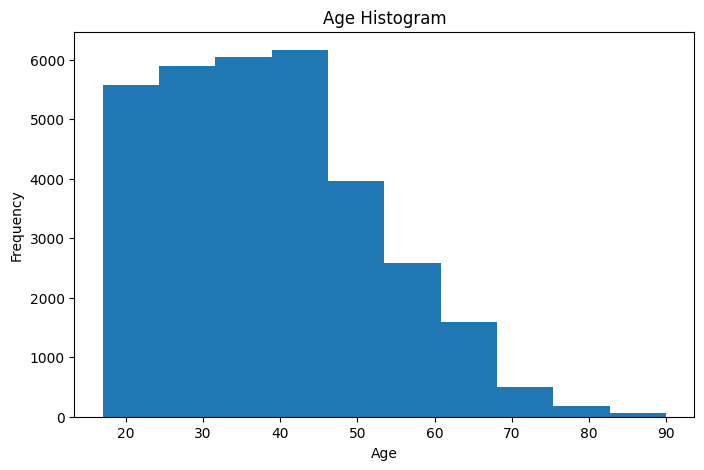

In [9]:

plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=10)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Histogram")

plt.show()


Perform Quantile Binning on GPU


In [11]:
import pandas as pd

# GPU quantiles
quantiles = gdf["age"].quantile(
    [0,0.25,0.5,0.75,1.0]
)

print("Quantile Bin Edges")
print(quantiles)

# Convert quantiles to numpy array
bins = quantiles.to_pandas().values

# Perform binning using pandas
df["age_bins"] = pd.cut(
    df["age"],
    bins=bins,
    labels=False,
    include_lowest=True
)

print(df[["age","age_bins"]].head())

Quantile Bin Edges
0.00    17.0
0.25    28.0
0.50    37.0
0.75    48.0
1.00    90.0
Name: age, dtype: float64
   age  age_bins
0   39         2
1   50         3
2   38         2
3   53         3
4   28         0


Train and Compare CPU and GPU Models


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from cuml.ensemble import RandomForestClassifier as cuRF

df_encoded = pd.get_dummies(df)

X = df_encoded.drop("income_>50K", axis=1)

y = df_encoded["income_>50K"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#CPU MODEL
start = time.time()

cpu_model = RandomForestClassifier(
    n_estimators=100
)

cpu_model.fit(X_train, y_train)
cpu_pred = cpu_model.predict(X_test)
cpu_time = time.time() - start
cpu_acc = accuracy_score(
    y_test,
    cpu_pred
)

print("CPU Accuracy:", cpu_acc)
print("CPU Time:", cpu_time)

# GPU MODEL
gX_train = cudf.from_pandas(X_train)
gX_test = cudf.from_pandas(X_test)
gy_train = cudf.Series(y_train)
start = time.time()

gpu_model = cuRF(
    n_estimators=100
)

gpu_model.fit(gX_train, gy_train)
gpu_pred = gpu_model.predict(gX_test)
gpu_time = time.time() - start
gpu_acc = accuracy_score(
    y_test,
    cp.asnumpy(gpu_pred.values)
)
print("GPU Accuracy:", gpu_acc)
print("GPU Time:", gpu_time)
print("Speedup:",
      cpu_time / gpu_time)

CPU Accuracy: 1.0
CPU Time: 1.5189461708068848
GPU Accuracy: 1.0
GPU Time: 0.4603259563446045
Speedup: 3.299718709908652



## XGBoost GPU Implementation


In [17]:
import xgboost as xgb
import re
import time
from sklearn.metrics import accuracy_score

# Clean column names
X_train.columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col)
    for col in X_train.columns
]

X_test.columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col)
    for col in X_test.columns
]

# XGBoost GPU
start = time.time()

xgb_model = xgb.XGBClassifier(
    tree_method='hist',
    device='cuda'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_time = time.time() - start

xgb_acc = accuracy_score(
    y_test,
    xgb_pred
)

print("XGBoost GPU Accuracy:",
      xgb_acc)

print("XGBoost GPU Time:",
      xgb_time)

XGBoost GPU Accuracy: 1.0
XGBoost GPU Time: 0.9046597480773926


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [18:54:29] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Q2. Implement a Random Forest classifier using both scikit-learn (CPU) and RAPIDS cuML (GPU) on the UCI Breast Cancer Dataset.

Tasks:
- Data Preparation
- CPU Implementation
- GPU Implementation
- Visualization of Parallelism
- Performance Comparison


Data Preparation


In [18]:

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

gX_train = cudf.DataFrame(X_train)
gX_test = cudf.DataFrame(X_test)

gy_train = cudf.Series(y_train)


CPU Implementation


In [19]:

start = time.time()

cpu_rf = RandomForestClassifier(
    n_estimators=100
)

cpu_rf.fit(X_train, y_train)

cpu_train_time = time.time() - start

start = time.time()

cpu_pred = cpu_rf.predict(X_test)

cpu_pred_time = time.time() - start

cpu_acc = accuracy_score(y_test, cpu_pred)

print("CPU Accuracy:", cpu_acc)
print("CPU Train Time:", cpu_train_time)
print("CPU Prediction Time:", cpu_pred_time)


CPU Accuracy: 0.9649122807017544
CPU Train Time: 0.24367141723632812
CPU Prediction Time: 0.007032155990600586


 GPU Implementation


In [20]:

start = time.time()

gpu_rf = cuRF(
    n_estimators=100
)

gpu_rf.fit(gX_train, gy_train)

gpu_train_time = time.time() - start

start = time.time()

gpu_pred = gpu_rf.predict(gX_test)

gpu_pred_time = time.time() - start

gpu_acc = accuracy_score(
    y_test,
    cp.asnumpy(gpu_pred.values)
)

print("GPU Accuracy:", gpu_acc)
print("GPU Train Time:", gpu_train_time)
print("GPU Prediction Time:", gpu_pred_time)

print("GPU Speedup:",
      cpu_train_time / gpu_train_time)


GPU Accuracy: 0.9649122807017544
GPU Train Time: 0.2801704406738281
GPU Prediction Time: 0.33525872230529785
GPU Speedup: 0.8697256450405065


 Forest-Level Parallelism


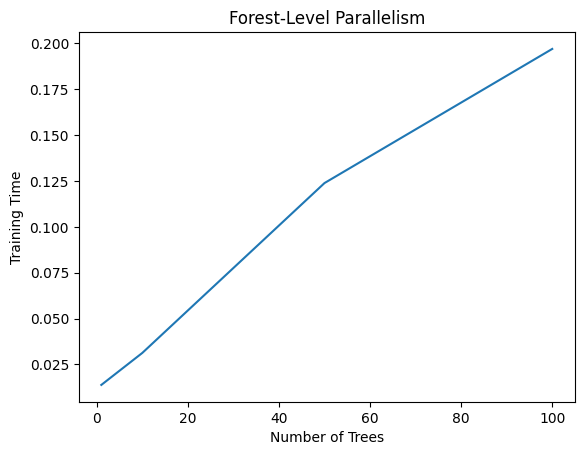

In [21]:

trees = [1,10,50,100]

times = []

for n in trees:

    start = time.time()

    model = cuRF(n_estimators=n)

    model.fit(gX_train, gy_train)

    t = time.time() - start

    times.append(t)

plt.plot(trees, times)

plt.xlabel("Number of Trees")
plt.ylabel("Training Time")
plt.title("Forest-Level Parallelism")

plt.show()


Feature-Level Parallelism


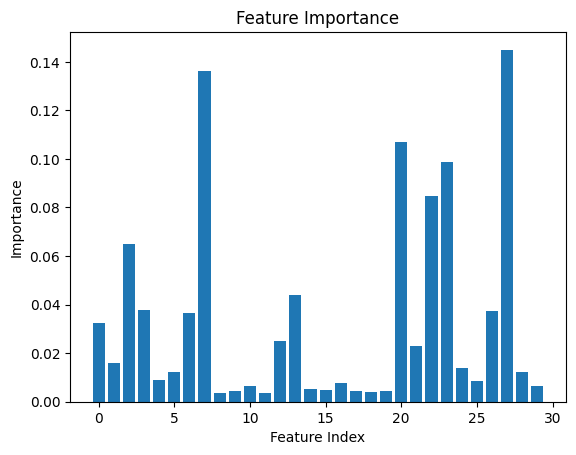

In [22]:

importance = cpu_rf.feature_importances_

plt.bar(range(len(importance)), importance)

plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.show()


Data-Level Parallelism


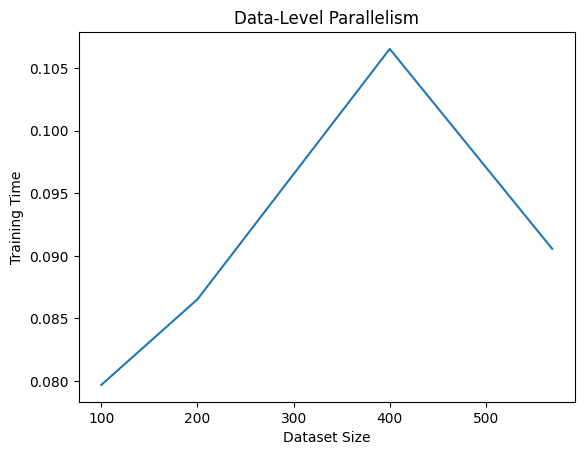

In [26]:
sizes = [100,200,400,569]

times = []

for s in sizes:

    start = time.time()

    model = cuRF(
        n_estimators=100,
        n_bins=16
    )

    model.fit(
        gX_train.iloc[:s],
        gy_train.iloc[:s]
    )

    t = time.time() - start

    times.append(t)

plt.plot(sizes, times)

plt.xlabel("Dataset Size")

plt.ylabel("Training Time")

plt.title("Data-Level Parallelism")

plt.show()

Bin-Level Parallelism


In [24]:

feature_gpu = cp.asarray(gX_train[0])

hist, bins = cp.histogram(feature_gpu, bins=10)

print("GPU Histogram")
print(hist)


GPU Histogram
[ 33  88 139  84  33  44  23   5   3   3]


Performance Comparison Graph


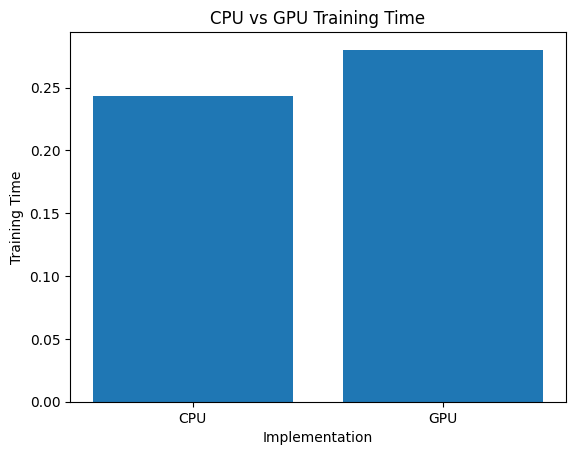

In [25]:

labels = ["CPU","GPU"]

train_times = [
    cpu_train_time,
    gpu_train_time
]

plt.bar(labels, train_times)

plt.xlabel("Implementation")
plt.ylabel("Training Time")
plt.title("CPU vs GPU Training Time")

plt.show()
